<a href="https://colab.research.google.com/github/giolanta-nta/Homework/blob/main/Week_5_DT_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', 1000)
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/datajour-gr/ML-algorithms/refs/heads/master/week%205/recipes.csv")

In [3]:
df.dtypes

,0
cuisine,object
id,int64
ingredient_list,object


In [4]:
df.shape

(39774, 3)

In [5]:
df.describe()

,id
count,39774.000000
mean,24849.536959
std,14360.035505
min,0.000000
25%,12398.250000
50%,24887.000000
75%,37328.500000
max,49717.000000


In [103]:
df['is_italian'] = (df['cuisine'] == 'italian').astype(int)
df.head()

,cuisine,id,ingredient_list,is_italian
0,greek,10259,"romaine lettuce, black olives, grape tomatoes, garlic, pepper, purple onion, seasoning, garbanzo beans, feta cheese crumbles",0
1,southern_us,25693,"plain flour, ground pepper, salt, tomatoes, ground black pepper, thyme, eggs, green tomatoes, yellow corn meal, milk, vegetable oil",0
2,filipino,20130,"eggs, pepper, salt, mayonaise, cooking oil, green chilies, grilled chicken breasts, garlic powder, yellow onion, soy sauce, butter, chicken livers",0
3,indian,22213,"water, vegetable oil, wheat, salt",0
4,indian,13162,"black pepper, shallots, cornflour, cayenne pepper, onions, garlic paste, milk, butter, salt, lemon juice, water, chili powder, passata, oil, ground cumin, boneless chicken skinless thigh, garam masala, double cream, natural yogurt, bay leaf",0


In [112]:
df_is_italian = df[df['cuisine'] == 'italian']
display(df_is_italian.head())

,cuisine,id,ingredient_list,is_italian
7,italian,3735,"sugar, pistachio nuts, white almond bark, flour, vanilla extract, olive oil, almond extract, eggs, baking powder, dried cranberries",1
9,italian,12734,"chopped tomatoes, fresh basil, garlic, extra-virgin olive oil, kosher salt, flat leaf parsley",1
10,italian,5875,"pimentos, sweet pepper, dried oregano, olive oil, garlic, sharp cheddar cheese, pepper, swiss cheese, provolone cheese, canola oil, mushrooms, black olives, sausages",1
12,italian,2698,"Italian parsley leaves, walnuts, hot red pepper flakes, extra-virgin olive oil, fresh lemon juice, trout fillet, garlic cloves, chipotle chile, fine sea salt, flat leaf parsley",1
14,italian,31908,"fresh parmesan cheese, butter, all-purpose flour, fat free less sodium chicken broth, chopped fresh chives, gruyere cheese, ground black pepper, bacon slices, gnocchi, fat free milk, cooking spray, salt",1


In [34]:
df.ingredient_list.str.contains("tomato").astype(int)

,ingredient_list
0,1
1,1
2,0
3,0
4,0
...,...
39769,0
39770,0
39771,0
39772,0


In [35]:
df_tomato_recipes = df[df.ingredient_list.str.contains("tomato")]
display(df_tomato_recipes.head())

,cuisine,id,ingredient_list
0,greek,10259,"romaine lettuce, black olives, grape tomatoes, garlic, pepper, purple onion, seasoning, garbanzo beans, feta cheese crumbles"
1,southern_us,25693,"plain flour, ground pepper, salt, tomatoes, ground black pepper, thyme, eggs, green tomatoes, yellow corn meal, milk, vegetable oil"
9,italian,12734,"chopped tomatoes, fresh basil, garlic, extra-virgin olive oil, kosher salt, flat leaf parsley"
13,mexican,41995,"ground cinnamon, fresh cilantro, chili powder, ground coriander, kosher salt, ground black pepper, garlic, plum tomatoes, avocado, lime juice, flank steak, salt, ground cumin, black pepper, olive oil, crushed red pepper flakes, onions"
15,indian,24717,"tumeric, vegetable stock, tomatoes, garam masala, naan, red lentils, red chili peppers, onions, spinach, sweet potatoes"


In [17]:
df_italian_ingredients = df[df.ingredient_list.str.contains("tomato|olive_oil|soy_sauce", case=False)]
display(df_italian_ingredients.head())

,cuisine,id,ingredient_list
0,greek,10259,"romaine lettuce, black olives, grape tomatoes, garlic, pepper, purple onion, seasoning, garbanzo beans, feta cheese crumbles"
1,southern_us,25693,"plain flour, ground pepper, salt, tomatoes, ground black pepper, thyme, eggs, green tomatoes, yellow corn meal, milk, vegetable oil"
9,italian,12734,"chopped tomatoes, fresh basil, garlic, extra-virgin olive oil, kosher salt, flat leaf parsley"
13,mexican,41995,"ground cinnamon, fresh cilantro, chili powder, ground coriander, kosher salt, ground black pepper, garlic, plum tomatoes, avocado, lime juice, flank steak, salt, ground cumin, black pepper, olive oil, crushed red pepper flakes, onions"
15,indian,24717,"tumeric, vegetable stock, tomatoes, garam masala, naan, red lentils, red chili peppers, onions, spinach, sweet potatoes"


In the code above, `case=False` makes the search case-insensitive, so it will match 'Tomato', 'tomato', 'TOMATO', etc. You can add as many ingredients as you like, separated by `|` = OR.

In [36]:
features_df = pd.DataFrame({
    'has_tomatoes': df.ingredient_list.str.contains('tomato').astype(int),
    'has_olive_oil': df.ingredient_list.str.contains('olive oil').astype(int),
    'has_soy_sauce': df.ingredient_list.str.contains('soy sauce').astype(int)
})
features_df.head(3)

,has_tomatoes,has_olive_oil,has_soy_sauce
0,1,0,0
1,1,0,0
2,0,0,1


In [76]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
estimator = DecisionTreeClassifier(max_leaf_nodes=4, random_state=0)

In [82]:
x = df['ingredient_list']
y = df['cuisine']

In [67]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [94]:
features_df = pd.DataFrame({
    'has_tomatoes': df.ingredient_list.str.contains('tomato').astype(int),
    'has_olive_oil': df.ingredient_list.str.contains('olive oil').astype(int),
    'has_soy_sauce': df.ingredient_list.str.contains('soy sauce').astype(int),
    'has_basil': df.ingredient_list.str.contains('basil').astype(int)

})
features_df.head(3)

,has_tomatoes,has_olive_oil,has_soy_sauce,has_basil
0,1,0,0,0
1,1,0,0,0
2,0,0,1,0


In [109]:
X_train, X_test, y_train, y_test = train_test_split(features_df.values, df.is_italian, test_size=0.2)

In [96]:
estimator.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=4, random_state=0)

In [97]:
val_pred = estimator.predict(X_test)

In [98]:
f1_score(y_test, val_pred, average='macro')

0.6001679176274602

In [99]:
fi = pd.DataFrame(estimator.feature_importances_, features_df.columns)
fi.columns = ['Importance']
fi.sort_values(by = 'Importance', ascending=False)[0:20]

,Importance
has_olive_oil,0.606672
has_basil,0.393328
has_tomatoes,0.000000
has_soy_sauce,0.000000


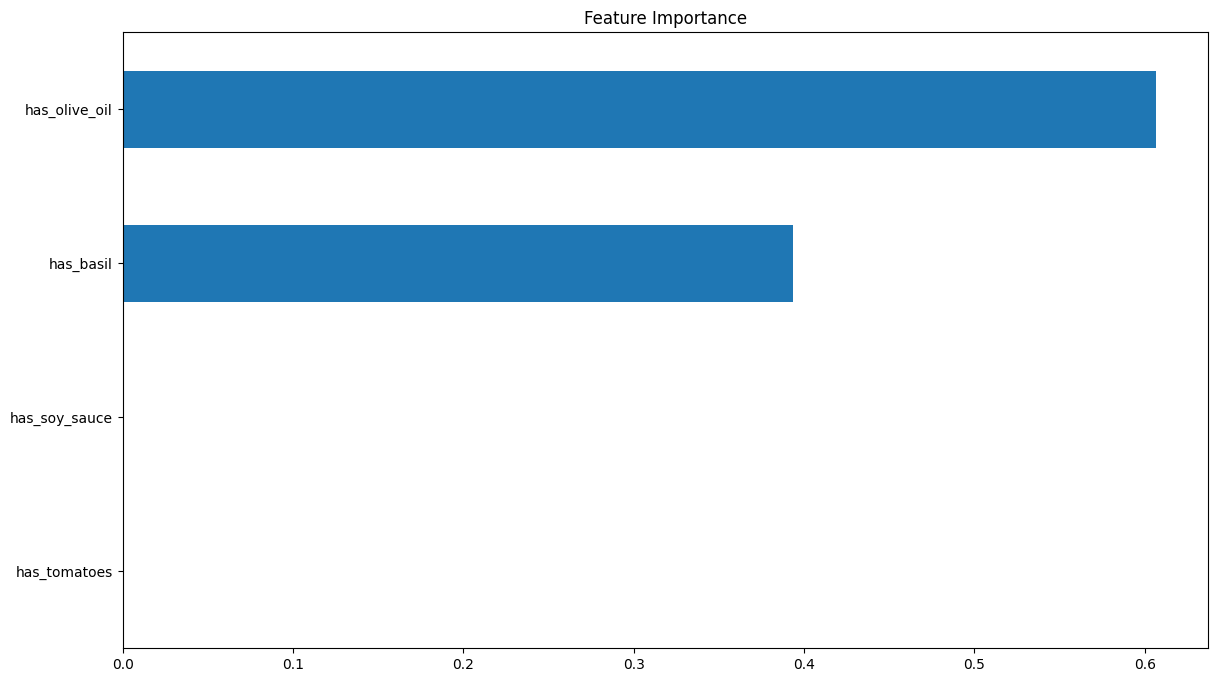

In [100]:
plot = fi.sort_values(by = 'Importance', ascending=True).tail(15).plot.barh(figsize = (14,8), legend = False, title = 'Feature Importance')
fig = plot.get_figure()

In [119]:
df_greek = df[df['cuisine'] == 'greek']
display(df_greek.head())

,cuisine,id,ingredient_list,is_italian
0,greek,10259,"romaine lettuce, black olives, grape tomatoes, garlic, pepper, purple onion, seasoning, garbanzo beans, feta cheese crumbles",0
93,greek,34471,"ground pork, finely chopped fresh parsley, onions, salt, vinegar, caul fat",0
103,greek,4635,"minced garlic, dried oregano, red wine vinegar, olive oil, boneless chop pork, lemon juice",0
153,greek,5980,"orange, anise, cinnamon sticks, unflavored gelatin, zinfandel, orange blossom honey, sugar, lemon, calimyrna figs, clove, honey, whipping cream, plain whole-milk yogurt",0
186,greek,18031,"fresh dill, yoghurt, salt, myzithra, large eggs, cheese, feta cheese, phyllo, kefalotyri, ground black pepper, extra-virgin olive oil, onions",0


In [127]:
df['is_greek'] = (df['cuisine'] == 'greek').astype(int)

In [120]:
features_df = pd.DataFrame({
    'tomatoes': df.ingredient_list.str.contains('tomato').astype(int),
    'olive_oil': df.ingredient_list.str.contains('olive oil').astype(int),
    'garlic': df.ingredient_list.str.contains('garlic').astype(int),
    'basil': df.ingredient_list.str.contains('basil').astype(int)
})
features_df.head(3)

,tomatoes,olive_oil,garlic,basil
0,1,0,1,0
1,1,0,0,0
2,0,0,1,0


In [129]:
X_train, X_test, y_train, y_test = train_test_split(features_df.values, df.is_greek, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (31819, 4), y_train shape: (31819,)
X_test shape: (7955, 4), y_test shape: (7955,)


In [130]:
estimator = DecisionTreeClassifier(max_leaf_nodes=4, random_state=0)

In [132]:
estimator.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=4, random_state=0)

In [133]:
val_pred = estimator.predict(X_test)

In [134]:
f1_score(y_test, val_pred, average='macro')

0.49205031607177063

In [135]:
fi = pd.DataFrame(estimator.feature_importances_, features_df.columns)
fi.columns = ['Importance']
fi.sort_values(by = 'Importance', ascending=False)[0:20]

,Importance
olive_oil,0.855770
basil,0.100280
tomatoes,0.043949
garlic,0.000000


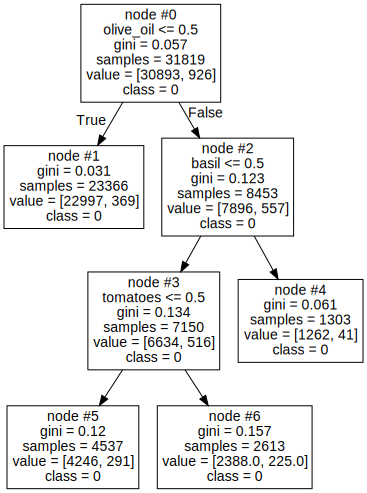

In [136]:
import graphviz
from sklearn.tree import export_graphviz

dot_data = export_graphviz(estimator)
graphviz.Source(export_graphviz(estimator,
                                out_file=None,
                                feature_names=features_df.columns,
                                class_names=["0", "1"],
                                node_ids = True,
                                impurity=True))